In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
print(os.getcwd())

C:\Repos\covid_health\sandra


In [2]:
# Load the dataset
data = pd.read_csv('adverse_react.csv', low_memory=False)
data

,VAERS_ID,RECVDATE,STATE,AGE_YRS,SEX,DIED,DATEDIED,RECOVD,VAX_DATE,ONSET_DATE,NUMDAYS,V_ADMINBY,VAX_MANU,HISTORY,ALLERGIES,Unnamed: 15
0,1261766,4/27/2021,FL,1,M,Y,4/10/2021,N,4/8/2021,4/10/2021,2.0,UNK,MODERNA,NaN,NaN,NaN
1,1543319,8/11/2021,CO,1,M,NaN,NaN,N,2/1/2021,2/2/2021,1.0,UNK,MODERNA,Medical History/Concurrent Conditions: Exposur...,NaN,NaN
2,1099241,3/14/2021,CA,1,F,NaN,NaN,N,3/10/2021,3/11/2021,1.0,PVT,JANSSEN,NaN,NaN,NaN
3,1263400,4/27/2021,TX,1,F,NaN,NaN,N,4/13/2021,4/25/2021,12.0,MIL,PFIZER\BIONTECH,N/a,N/a,NaN
4,1420157,6/23/2021,NJ,1,M,NaN,NaN,N,5/22/2021,6/4/2021,13.0,UNK,MODERNA,No,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
636242,920832,1/5/2021,NY,104,F,Y,1/4/2021,U,12/30/2020,1/1/2021,2.0,UNK,PFIZER\BIONTECH,NaN,NaN,NaN
636243,1233604,4/20/2021,WI,104,F,Y,4/14/2021,U,2/26/2021,4/14/2021,47.0,SEN,MODERNA,NaN,NaN,NaN
636244,1292173,5/6/2021,MN,105,M,NaN,NaN,U,3/24/2021,3/31/2021,7.0,OTH,PFIZER\BIONTECH,NaN,NaN,NaN
636245,1314020,5/13/2021,NaN,105,F,NaN,NaN,U,4/14/2021,5/10/2021,26.0,UNK,PFIZER\BIONTECH,NaN,NaN,NaN


[]


C:\Users\Sandra\AppData\Local\Temp\ipykernel_64896\466885531.py:20: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x='AGE_YRS', y='DIED_jitter', hue='SEX', palette=custom_palette, s=50, alpha=0.8)


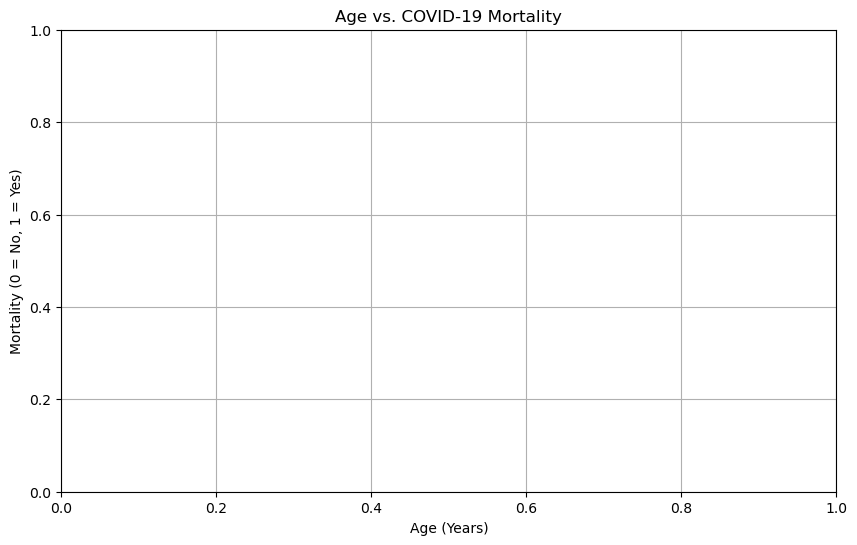

In [4]:
# Convert 'DIED' to numeric
df['DIED'] = df['DIED'].map({'Yes': 1, 'No': 0})

# Handle missing or unknown values
df = df.dropna(subset=['AGE_YRS', 'DIED'])  # Remove NaN values
df['SEX'] = df['SEX'].fillna('Unknown').astype(str).str.strip()  # Ensure 'SEX' has valid values

# Verify 'SEX' column
print(df['SEX'].unique())  

# Define color palette based on actual values
valid_sex_values = df['SEX'].unique()
custom_palette = {val: color for val, color in zip(valid_sex_values, ['blue', 'red', 'gray', 'black'])}

# Add jitter to 'DIED' for better visibility
df['DIED_jitter'] = df['DIED'] + np.random.uniform(-0.02, 0.02, size=len(df))

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='AGE_YRS', y='DIED_jitter', hue='SEX', palette=custom_palette, s=50, alpha=0.8)

plt.title('Age vs. COVID-19 Mortality')
plt.xlabel('Age (Years)')
plt.ylabel('Mortality (0 = No, 1 = Yes)')
plt.grid(True)
plt.show()

